<a href="https://colab.research.google.com/github/nemo10-boop/WUEKM/blob/main/Classical_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision scikit-image matplotlib seaborn

import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMG_SIZE, BATCH_SIZE, EPOCHS, LR, NUM_WORKERS = 28, 4, 100, 1e-3, 2
print(f"Device: {DEVICE} | IMG:{IMG_SIZE} | BS:{BATCH_SIZE} | EP:{EPOCHS} | LR:{LR}")

Device: cuda | IMG:28 | BS:4 | EP:100 | LR:0.001


In [2]:
def filter_binary(dataset, class_a, class_b, max_per_class=None):
    targets = np.array(dataset.targets)
    idx_a = np.where(targets == class_a)[0]
    idx_b = np.where(targets == class_b)[0]
    if max_per_class:
        idx_a, idx_b = idx_a[:max_per_class], idx_b[:max_per_class]
    indices = np.concatenate([idx_a, idx_b])
    np.random.shuffle(indices)
    new_targets = targets.copy()
    new_targets[targets == class_a] = 0
    new_targets[targets == class_b] = 1
    dataset.targets = new_targets.tolist()
    return Subset(dataset, indices)

def split_dataset(dataset, train_n, val_n, test_n):
    leftover = len(dataset) - train_n - val_n - test_n
    return random_split(dataset, [train_n, val_n, test_n, leftover],
                        generator=torch.Generator().manual_seed(SEED))[:3]

def make_loaders(train_ds, val_ds, test_ds):
    return {
        'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
        'val':   DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        'test':  DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    }

print("Helpers ready")

Helpers ready


In [3]:
base_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST (3 vs 5)
mnist_tr = filter_binary(datasets.MNIST('./data', train=True,  download=True, transform=base_tf), 3, 5, 3125)
mnist_te = filter_binary(datasets.MNIST('./data', train=False, download=True, transform=base_tf), 3, 5, 500)
mnist_loaders = make_loaders(*split_dataset(mnist_tr, 5000, 1250, 0)[:2], mnist_te)

# Fashion-MNIST (T-shirt vs Trouser)
fm_tr = filter_binary(datasets.FashionMNIST('./data', train=True,  download=True, transform=base_tf), 0, 1, 3125)
fm_te = filter_binary(datasets.FashionMNIST('./data', train=False, download=True, transform=base_tf), 0, 1, 500)
fmnist_loaders = make_loaders(*split_dataset(fm_tr, 5000, 1250, 0)[:2], fm_te)

print("MNIST & F-MNIST ready")

# Brain Tumor MRI — Kaggle download
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -q

class MRIBinaryDataset(Dataset):
    BENIGN    = {'notumor', 'no tumor'}
    MALIGNANT = {'glioma', 'meningioma', 'pituitary'}

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []
        for ext in ('*.jpg', '*.png'):
            for p in Path(root).rglob(ext):
                folder = p.parent.name.lower().replace('_', ' ').replace('-', ' ')
                if any(b in folder for b in self.BENIGN):
                    self.samples.append((str(p), 0))
                elif any(m in folder for m in self.MALIGNANT):
                    self.samples.append((str(p), 1))
        np.random.shuffle(self.samples)
        labels = [s[1] for s in self.samples]
        print(f"MRI total:{len(self.samples)}  Benign:{labels.count(0)}  Malignant:{labels.count(1)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        return self.transform(img) if self.transform else img, label

mri_full = MRIBinaryDataset('/content', transform=base_tf)
mri_loaders = make_loaders(*split_dataset(mri_full, 2089, 653, 523))
print("MRI ready")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]
100%|██████████| 26.4M/26.4M [00:03<00:00, 8.03MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.3MB/s]

MNIST & F-MNIST ready


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
MRI total:7200  Benign:1800  Malignant:5400
MRI ready


In [4]:
class ClassicalCNN(nn.Module):
    def __init__(self, in_channels=1, img_size=28):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),          nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
        )
        flat = self.features(torch.zeros(1, in_channels, img_size, img_size)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 64), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x): return self.classifier(self.features(x))

# Sanity check
m = ClassicalCNN().to(DEVICE)
print(m)
print(f"\nParams: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")
print(f"Output: {tuple(m(torch.randn(4,1,28,28).to(DEVICE)).shape)}")

ClassicalCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Params: 105,377
Output: (4, 1)


In [5]:
def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += ((torch.sigmoid(out) >= 0.5).float() == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

def train_model(name, loaders):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    model     = ClassicalCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=7, factor=0.5)
    history   = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc')}
    best_acc, best_state, stagnant = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, loaders['train'], optimizer, criterion, train=True)
        va_loss, va_acc = run_epoch(model, loaders['val'],   optimizer, criterion, train=False)
        for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc]): history[k].append(v)
        scheduler.step(va_acc)
        if va_acc > best_acc:
            best_acc, best_state, stagnant = va_acc, {k: v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            stagnant += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d} | train {tr_acc*100:.2f}% {tr_loss:.4f} | val {va_acc*100:.2f}% {va_loss:.4f}")
        if stagnant >= 15:
            print(f"  Early stop @ epoch {epoch}"); break

    model.load_state_dict(best_state)
    print(f"\n  Best val: {best_acc*100:.2f}%")
    return model, history

print("Training functions ready")

Training functions ready


In [6]:
mnist_model,  mnist_hist  = train_model('MNIST  (3 vs 5)',               mnist_loaders)
fmnist_model, fmnist_hist = train_model('F-MNIST (T-shirt vs Trouser)',   fmnist_loaders)
mri_model,    mri_hist    = train_model('MRI Brain Tumor',                mri_loaders)

torch.save(mnist_model.state_dict(),  'cnn_mnist.pt')
torch.save(fmnist_model.state_dict(), 'cnn_fmnist.pt')
torch.save(mri_model.state_dict(),    'cnn_mri.pt')
print("Models saved.")


  MNIST  (3 vs 5)
  Ep   1 | train 96.54% 0.0851 | val 98.00% 0.0604
  Ep  10 | train 99.78% 0.0093 | val 99.52% 0.0316
  Ep  20 | train 99.98% 0.0013 | val 99.44% 0.0431
  Ep  30 | train 100.00% 0.0000 | val 99.52% 0.0381
  Ep  40 | train 100.00% 0.0000 | val 99.36% 0.0603
  Early stop @ epoch 40

  Best val: 99.68%

  F-MNIST (T-shirt vs Trouser)
  Ep   1 | train 98.00% 0.0568 | val 97.04% 0.0958
  Ep  10 | train 99.74% 0.0090 | val 99.12% 0.0487
  Ep  20 | train 99.98% 0.0008 | val 99.60% 0.0561
  Ep  30 | train 100.00% 0.0001 | val 99.60% 0.0690
  Early stop @ epoch 34

  Best val: 99.60%

  MRI Brain Tumor
  Ep   1 | train 89.18% 0.2925 | val 92.65% 0.1928
  Ep  10 | train 98.13% 0.0478 | val 95.41% 0.1665
  Ep  20 | train 98.71% 0.0322 | val 97.70% 0.1402
  Ep  30 | train 99.71% 0.0075 | val 97.55% 0.1712
  Early stop @ epoch 35

  Best val: 97.70%
Models saved.


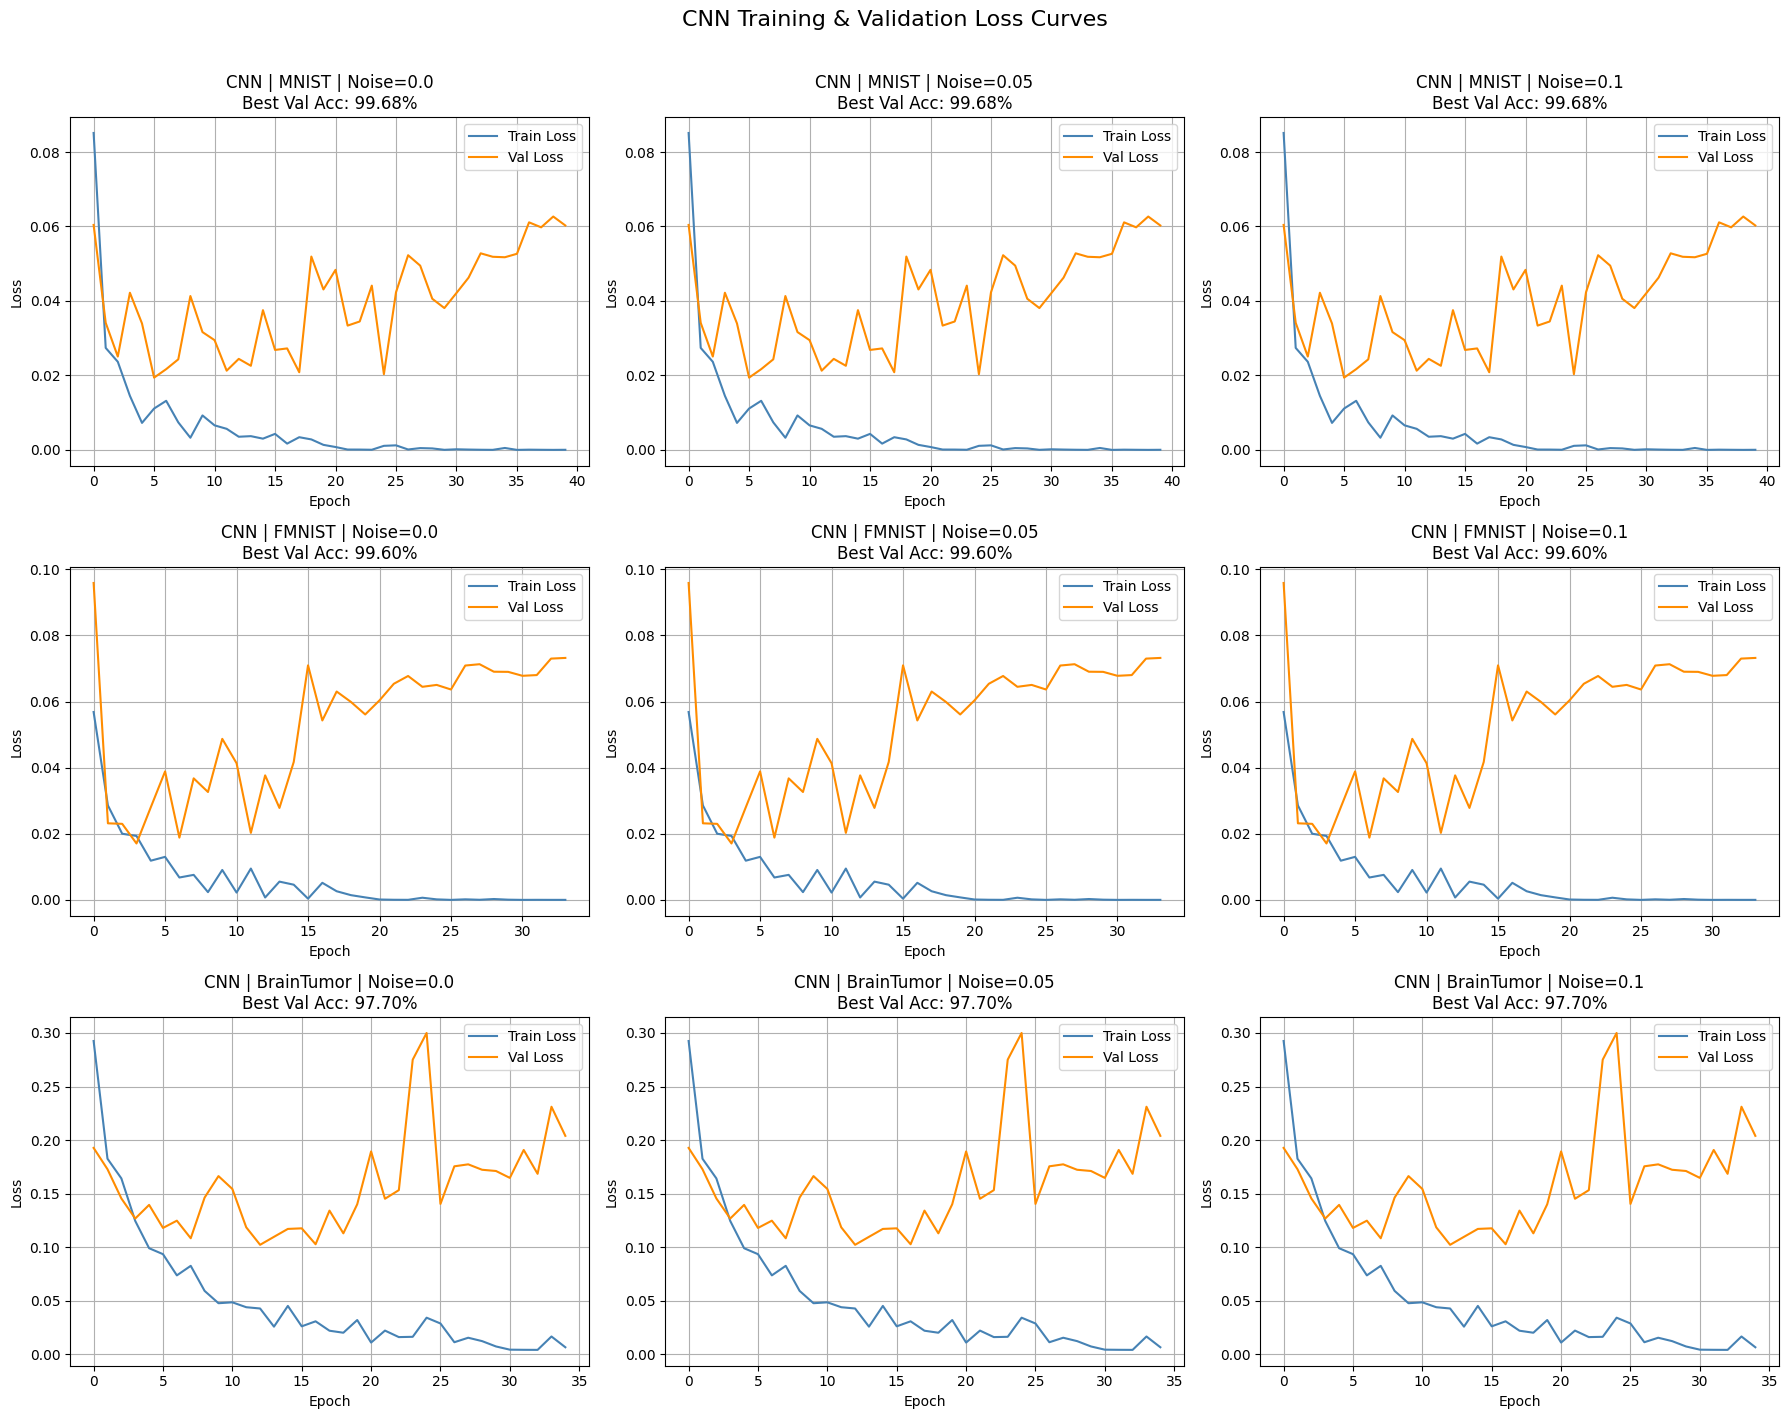

In [11]:
# ── Training curves ──────────────────────────────────────────────
NOISE_LABELS = [0.0, 0.05, 0.10]
ds_names     = ["MNIST", "FMNIST", "BrainTumor"]

histories = {
    "MNIST":      mnist_hist,
    "FMNIST":     fmnist_hist,
    "BrainTumor": mri_hist,
}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, ds in enumerate(ds_names):
    hist = histories[ds]
    for col, nl in enumerate(NOISE_LABELS):
        ax = axes[row][col]
        ax.plot(hist['train_loss'], label="Train Loss", color="steelblue")
        ax.plot(hist['val_loss'],   label="Val Loss",   color="darkorange")
        ax.set_title(f"CNN | {ds} | Noise={nl}\nBest Val Acc: {max(hist['val_acc'])*100:.2f}%")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)

plt.suptitle("CNN Training & Validation Loss Curves", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("cnn_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
criterion  = nn.BCEWithLogitsLoss()
paper_cnn  = {'MNIST': 98.79, 'F-MNIST': 99.19, 'MRI': 89.43}

print(f"\n{'='*52}")
print(f"  {'Dataset':<12} {'Our CNN':>10} {'Paper CNN':>12} {'Δ':>8}")
print(f"  {'-'*48}")
for name, (model, loader) in all_models.items():
    _, acc = run_epoch(model.to(DEVICE), loader, None, criterion, train=False)
    our = acc * 100
    print(f"  {name:<12} {our:>9.2f}%  {paper_cnn[name]:>9.2f}%  {our-paper_cnn[name]:>+7.2f}%")
print(f"{'='*52}")

# Classification reports
for name, (model, loader) in all_models.items():
    model.to(DEVICE).eval(); preds_all, labels_all = [], []
    with torch.no_grad():
        for x, y in loader:
            preds_all  += (torch.sigmoid(model(x.to(DEVICE))) >= 0.5).long().cpu().squeeze().tolist()
            labels_all += y.tolist()
    print(f"\n── {name} ──")
    print(classification_report(labels_all, preds_all, target_names=class_names[name]))


  Dataset         Our CNN    Paper CNN        Δ
  ------------------------------------------------
  MNIST            99.20%      98.79%    +0.41%
  F-MNIST          99.50%      99.19%    +0.31%
  MRI              96.18%      89.43%    +6.75%

── MNIST ──
              precision    recall  f1-score   support

     Digit 3       1.00      0.99      0.99       500
     Digit 5       0.99      1.00      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


── F-MNIST ──
              precision    recall  f1-score   support

     T-shirt       0.99      1.00      1.00       500
     Trouser       1.00      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000


── MRI ──
              precision    recall  f1-score   support

      Be

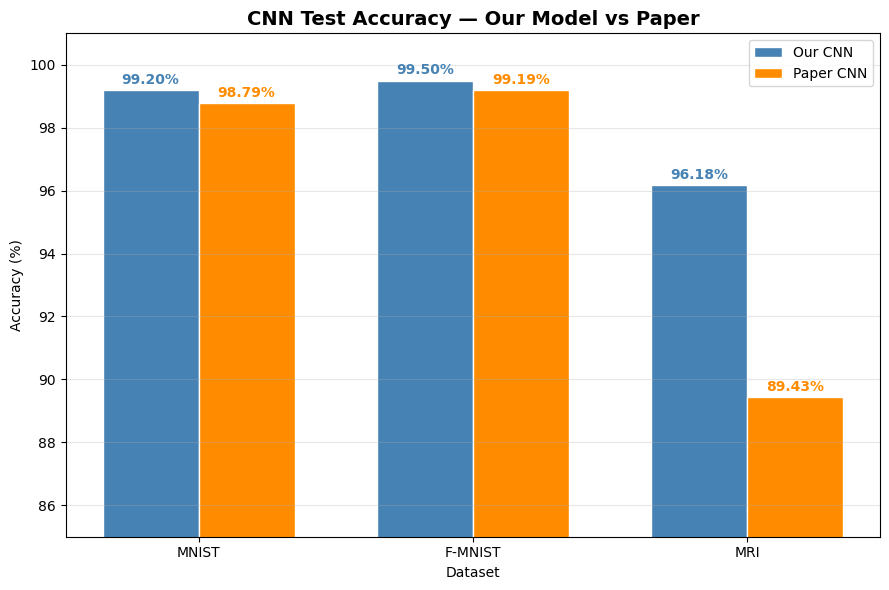

In [12]:
# ── Accuracy bar chart ───────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss()

our_accs   = {}
paper_accs = {'MNIST': 98.79, 'F-MNIST': 99.19, 'MRI': 89.43}

for name, (model, loader) in {
    'MNIST':   (mnist_model,  mnist_loaders['test']),
    'F-MNIST': (fmnist_model, fmnist_loaders['test']),
    'MRI':     (mri_model,    mri_loaders['test']),
}.items():
    _, acc = run_epoch(model.to(DEVICE), loader, None, criterion, train=False)
    our_accs[name] = acc * 100

# ── Plot ─────────────────────────────────────────────────────────
ds_labels = list(our_accs.keys())
our_vals   = [our_accs[k]   for k in ds_labels]
paper_vals = [paper_accs[k] for k in ds_labels]

x     = np.arange(len(ds_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(x - width/2, our_vals,   width, label='Our CNN',   color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + width/2, paper_vals, width, label='Paper CNN', color='darkorange', edgecolor='white')

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='steelblue', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, color='darkorange', fontweight='bold')

ax.set_title('CNN Test Accuracy — Our Model vs Paper', fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(ds_labels)
ax.set_ylim(85, 101)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()